# Compare Optimizers for Time- and Space-Averaged Lid Drag



## 0 · Notebook Loader

In [8]:
import json
from pathlib import Path

def run_notebook_cells(path, stop_on=None):
    candidate = Path(path)
    if not candidate.exists():
        candidate = Path("jax") / path

    with open(candidate) as f:
        nb = json.load(f)

    ns = {}
    for i, cell in enumerate(nb["cells"]):
        if cell["cell_type"] != "code":
            continue

        src = "".join(cell["source"])
        src = "\n".join(
            line for line in src.splitlines()
            if not line.strip().startswith("%")
        )

        if stop_on and stop_on in src:
            print(f"  Stopped before cell {i} (trigger: '{stop_on}')")
            break

        try:
            exec(src, ns)
        except Exception as e:
            print(f"  Cell {i} skipped - {type(e).__name__}: {e}")

    return ns


## 1 · Import the JAX Cavity-Flow Solver

In [9]:
print("Loading cavity_flow_jax.ipynb ...")
jax_ns = run_notebook_cells(
    "cavity_flow_jax.ipynb",
    stop_on="u_sol, v_sol, p_sol = cavity_flow",
)

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

build_up_b = jax_ns["build_up_b"]
pressure_poisson = jax_ns["pressure_poisson"]

nx = jax_ns["nx"]
ny = jax_ns["ny"]
nt = jax_ns["nt"]
dx = jax_ns["dx"]
dy = jax_ns["dy"]
rho = jax_ns["rho"]
nu = jax_ns["nu"]
dt = jax_ns["dt"]
X = jax_ns["X"]
Y = jax_ns["Y"]

print(f"Imported grid: nx={nx}, ny={ny}, nt={nt}")
print(f"Physics: rho={rho}, nu={nu}, dt={dt}, dx={dx}, dy={dy}")


Loading cavity_flow_jax.ipynb ...
  Stopped before cell 5 (trigger: 'u_sol, v_sol, p_sol = cavity_flow')
Imported grid: nx=41, ny=41, nt=1000
Physics: rho=1.0, nu=0.1, dt=0.001, dx=0.025, dy=0.025


## 2 ·  Simulation and Loss

In [ ]:
def top_wall_shear(u):
    return (u[:, -1] - u[:, -2]) / dy


def step_fn(carry, a_i):
    u, v, p, l_tot = carry

    b = build_up_b(jnp.zeros((nx, ny)), rho, dt, u, v, dx, dy)
    p = pressure_poisson(p, dx, dy, b)

    un, vn = u, v

    u = u.at[1:-1, 1:-1].set(
        un[1:-1, 1:-1]
        - un[1:-1, 1:-1] * dt / dx * (un[1:-1, 1:-1] - un[0:-2, 1:-1])
        - vn[1:-1, 1:-1] * dt / dy * (un[1:-1, 1:-1] - un[1:-1, 0:-2])
        - dt / (2 * rho * dx) * (p[2:, 1:-1] - p[0:-2, 1:-1])
        + nu * (
            dt / dx**2 * (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[0:-2, 1:-1])
            + dt / dy**2 * (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, 0:-2])
        )
    )

    v = v.at[1:-1, 1:-1].set(
        vn[1:-1, 1:-1]
        - un[1:-1, 1:-1] * dt / dx * (vn[1:-1, 1:-1] - vn[0:-2, 1:-1])
        - vn[1:-1, 1:-1] * dt / dy * (vn[1:-1, 1:-1] - vn[1:-1, 0:-2])
        - dt / (2 * rho * dy) * (p[1:-1, 2:] - p[1:-1, 0:-2])
        + nu * (
            dt / dx**2 * (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[0:-2, 1:-1])
            + dt / dy**2 * (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, 0:-2])
        )
    )

    u = u.at[:, 0].set(0.0)
    u = u.at[0, :].set(0.0)
    u = u.at[-1, :].set(0.0)
    u = u.at[:, -1].set(a_i)

    v = v.at[:, 0].set(0.0)
    v = v.at[:, -1].set(0.0)
    v = v.at[0, :].set(0.0)
    v = v.at[-1, :].set(0.0)
#IMPORTANT:
#Get top wall shear du/dy
    du_dy = top_wall_shear(u)
#current loss is spatial average of absolute value of du/dy along the top wall
    l_curr = jnp.mean(jnp.abs(du_dy))
#Update total loss
    l_tot = l_tot + l_curr
#return current state and du/dy for history
    return (u, v, p, l_tot), du_dy


def run_sim(a):
#inital conditions are
    u0 = jnp.zeros((nx, ny))
    v0 = jnp.zeros((nx, ny))
    p0 = jnp.zeros((nx, ny))
    l0 = 0.0
#putting l_tot in carry allows us to use jax.lax.scan to compute what we need for l_avg, and final state of flow
    (u_f, v_f, p_f, l_tot), du_dy_history = jax.lax.scan(step_fn, (u0, v0, p0, l0), a)
#COMPUTE AVG LOSS HERE
    l_avg = l_tot / nt
    return u_f, v_f, p_f, l_avg, du_dy_history

#define loss as average drag
def loss(a):
    u_f, v_f, p_f, l_avg, du_dy_history = run_sim(a)
    return l_avg

#gradient of loss with repsect to control parameters a
grad_fn = jax.jit(jax.value_and_grad(loss))

print("Simulation and loss defined.")


Simulation and loss defined.


## 3 · Initial Control and Bounds

In [11]:
t = jnp.arange(nt) * dt
total_time = nt * dt
phase = 2.0 * jnp.pi * t / total_time
a_min = 0.5
a_max = 2.5
a0 = jnp.sin(phase) + 1.5

print(f"a0 shape: {a0.shape}")
print(f"a0 min/max: {float(jnp.min(a0)):.6f}, {float(jnp.max(a0)):.6f}")
print(f"Bounds: [{a_min:.3f}, {a_max:.3f}]")


a0 shape: (1000,)
a0 min/max: 0.500000, 2.500000
Bounds: [0.500, 2.500]


## 4 · Validation

In [12]:
u_test, v_test, p_test, l_avg0, du_dy_hist0 = run_sim(a0)
loss0, grad0 = grad_fn(a0)

print(f"u_test shape: {u_test.shape}, finite={bool(jnp.isfinite(u_test).all())}")
print(f"v_test shape: {v_test.shape}, finite={bool(jnp.isfinite(v_test).all())}")
print(f"p_test shape: {p_test.shape}, finite={bool(jnp.isfinite(p_test).all())}")
print(f"du_dy history shape: {du_dy_hist0.shape}")
print(f"Initial time-avg |du/dy|: {float(l_avg0):.6f}")
print(f"grad shape: {grad0.shape}")
print(f"grad L2 norm: {float(jnp.linalg.norm(grad0)):.6e}")


u_test shape: (41, 41), finite=True
v_test shape: (41, 41), finite=True
p_test shape: (41, 41), finite=True
du_dy history shape: (1000, 41)
Initial time-avg |du/dy|: 19.144043
grad shape: (1000,)
grad L2 norm: 4.128801e-01


## 5 · Optimizer Helpers

In [13]:
def optimize_manual_gd(a_init, lr=3e-2, n_iters=150):
    a = a_init
    loss_history = []
    grad_norm_history = []

    for i in range(n_iters):
        val, grads = grad_fn(a)
        a = a - lr * grads
        a = jnp.clip(a, a_min, a_max)
        loss_history.append(float(val))
        grad_norm_history.append(float(jnp.linalg.norm(grads)))

    return {
        "name": "Manual GD",
        "a": a,
        "loss_history": loss_history,
        "grad_norm_history": grad_norm_history,
    }

#scipy optimizer
#Uses SciPy’s L-BFGS-B optimizer to find the best control input a that minimizes some loss (computed via grad_fn

#a_init: inital guess forinput
#maxiter: max number of iterations for optimizer
def optimize_scipy(a_init, maxiter=50):
#tracks how loss changes over optimizations
    eval_history = []

#scipy repeatedly calls objective
    def objective(x):
#convert to np array
        a = jnp.asarray(x)
#runs sim, computes loss, compute gradient
        val, grad = grad_fn(a)

        val_f = float(val)
#convert gradient to numpy array for scipy
        grad_np = np.array(grad, dtype=np.float64)
        eval_history.append(val_f)
#return both loss and grad
        return val_f, grad_np

    bounds = [(a_min, a_max)] * int(a_init.shape[0])
#core opttimizaion
    result = minimize(
    #loss fn
        fun=objective,
    #initial guess
        x0=np.array(a_init, dtype=np.float64),
        jac=True,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": maxiter, "disp": True},
    )
#get final results, and final gradient for history
    a = jnp.asarray(result.x)
    _, final_grad = grad_fn(a)
    return {
        "name": "SciPy L-BFGS-B",
        "a": a,
        "loss_history": eval_history,
        "grad_norm_history": [float(jnp.linalg.norm(final_grad))] * len(eval_history),
        "scipy_result": result,
    }


print("Optimizer helpers defined.")
#l-bfgs is a smart, memory-efficient optimizer that uses gradients to move toward a minimum, while respecting bounds on your variables.
#Only keeps a few past gradients + steps


Optimizer helpers defined.


## 6 · Run Optimizer

In [14]:
manual_gd_result = optimize_manual_gd(a0, lr=3e-2, n_iters=150)
scipy_result = optimize_scipy(a0, maxiter=50)

results = [manual_gd_result, scipy_result]
print("optimizer finished.")


/var/folders/lx/_xjzr43n0k51_q47r04c4nrw0000gn/T/ipykernel_63698/1371676219.py:45: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


optimizer finished.


## 7 · Summarize Final Metrics

In [15]:
summary = []
for result in results:
    a_opt = result["a"]
    final_loss, final_grads = grad_fn(a_opt)
    u_opt, v_opt, p_opt, l_avg_opt, du_dy_hist_opt = run_sim(a_opt)
    summary.append({
        "name": result["name"],
        "final_loss": float(final_loss),
        "iters_or_evals": len(result["loss_history"]),
        "control_min": float(jnp.min(a_opt)),
        "control_max": float(jnp.max(a_opt)),
        "max_abs_change": float(jnp.max(jnp.abs(a_opt - a0))),
        "grad_norm": float(jnp.linalg.norm(final_grads)),
        "finite_fields": bool(jnp.isfinite(u_opt).all()) and bool(jnp.isfinite(v_opt).all()) and bool(jnp.isfinite(p_opt).all()),
    })

for item in summary:
    print(item)


{'name': 'Manual GD', 'final_loss': 18.43168298148225, 'iters_or_evals': 150, 'control_min': 0.5, 'control_max': 2.443436337568936, 'max_abs_change': 0.18000000000001348, 'grad_norm': 0.41076974906018365, 'finite_fields': True}
{'name': 'SciPy L-BFGS-B', 'final_loss': 6.401546255820256, 'iters_or_evals': 6, 'control_min': 0.5, 'control_max': 0.5, 'max_abs_change': 2.0, 'grad_norm': 0.40939142845305915, 'finite_fields': True}


## 8 · Compare Loss Histories

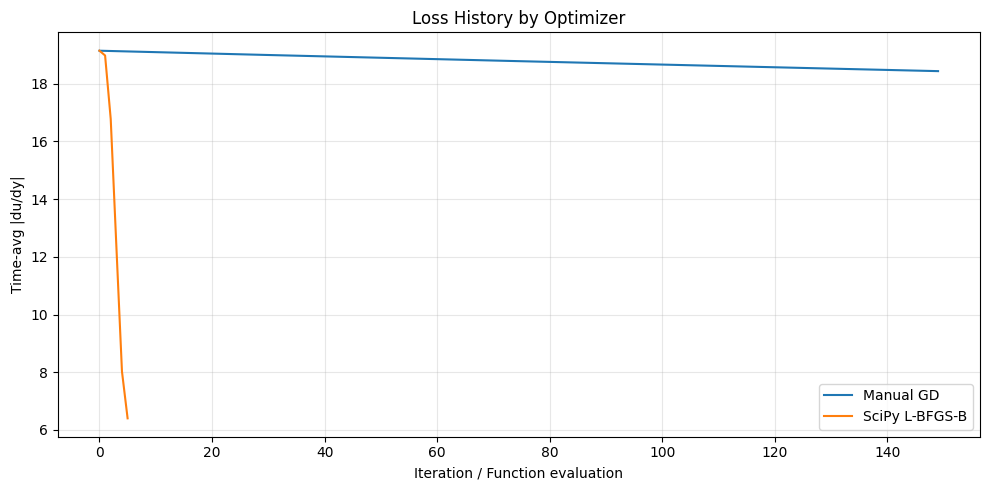

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
for result in results:
    ax.plot(result["loss_history"], label=result["name"])
ax.set_title("Loss History by Optimizer")
ax.set_xlabel("Iteration / Function evaluation")
ax.set_ylabel("Time-avg |du/dy|")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9 · Compare Optimized Lid Schedules

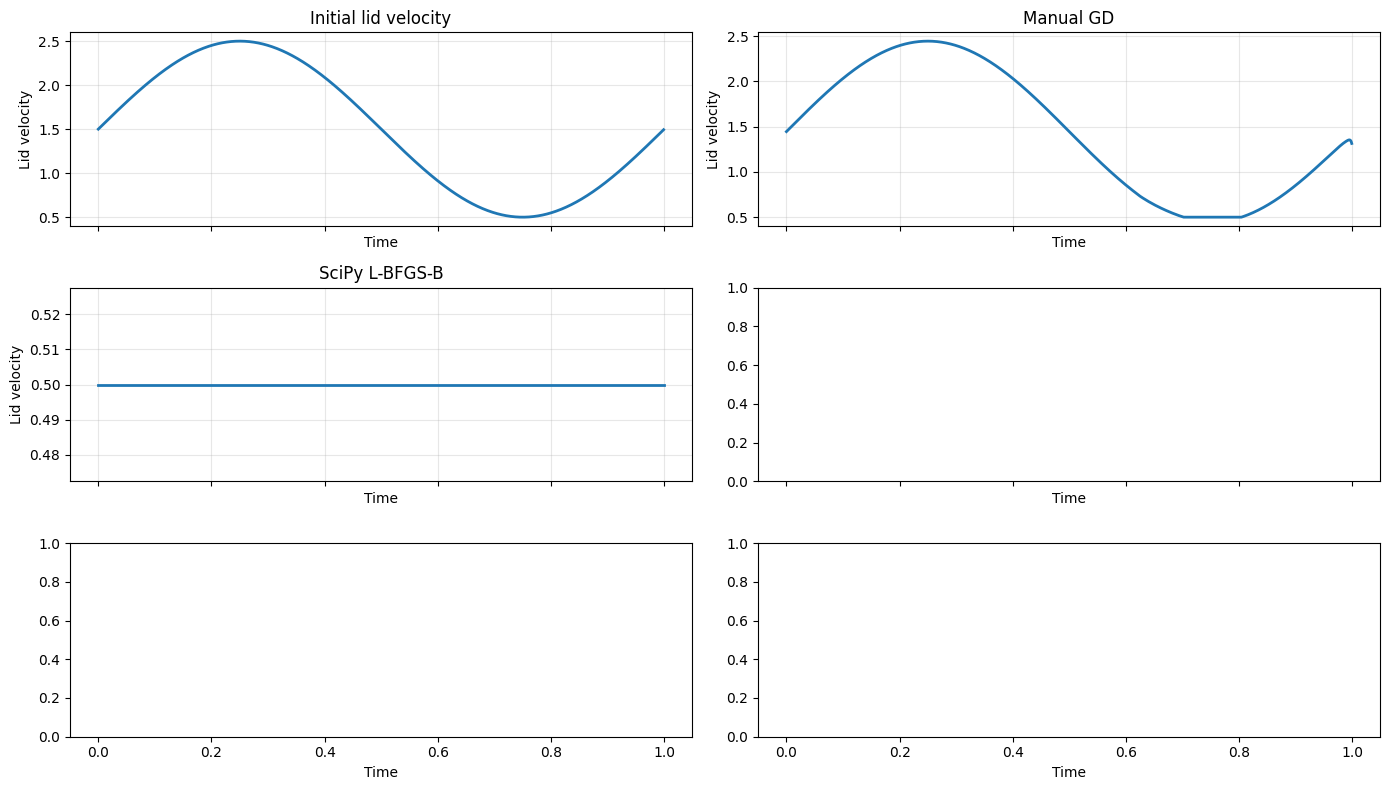

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex=True)
axes = axes.ravel()

axes[0].plot(np.array(t), np.array(a0), linewidth=2)
axes[0].set_title("Initial lid velocity")
axes[0].set_ylabel("Lid velocity")
axes[0].grid(alpha=0.3)

for ax, result in zip(axes[1:], results):
    ax.plot(np.array(t), np.array(result["a"]), linewidth=2)
    ax.set_title(result["name"])
    ax.set_ylabel("Lid velocity")
    ax.grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

#initial and final lid velocity
#a0 shape: (1000,)
#a0 min/max: 0.500000, 2.500000
#Bounds: [0.500, 2.500]

#I constraiend vleocity bounds to 0.5-->2.5

## 10 · Compare Drag Histories and Final Flow Fields

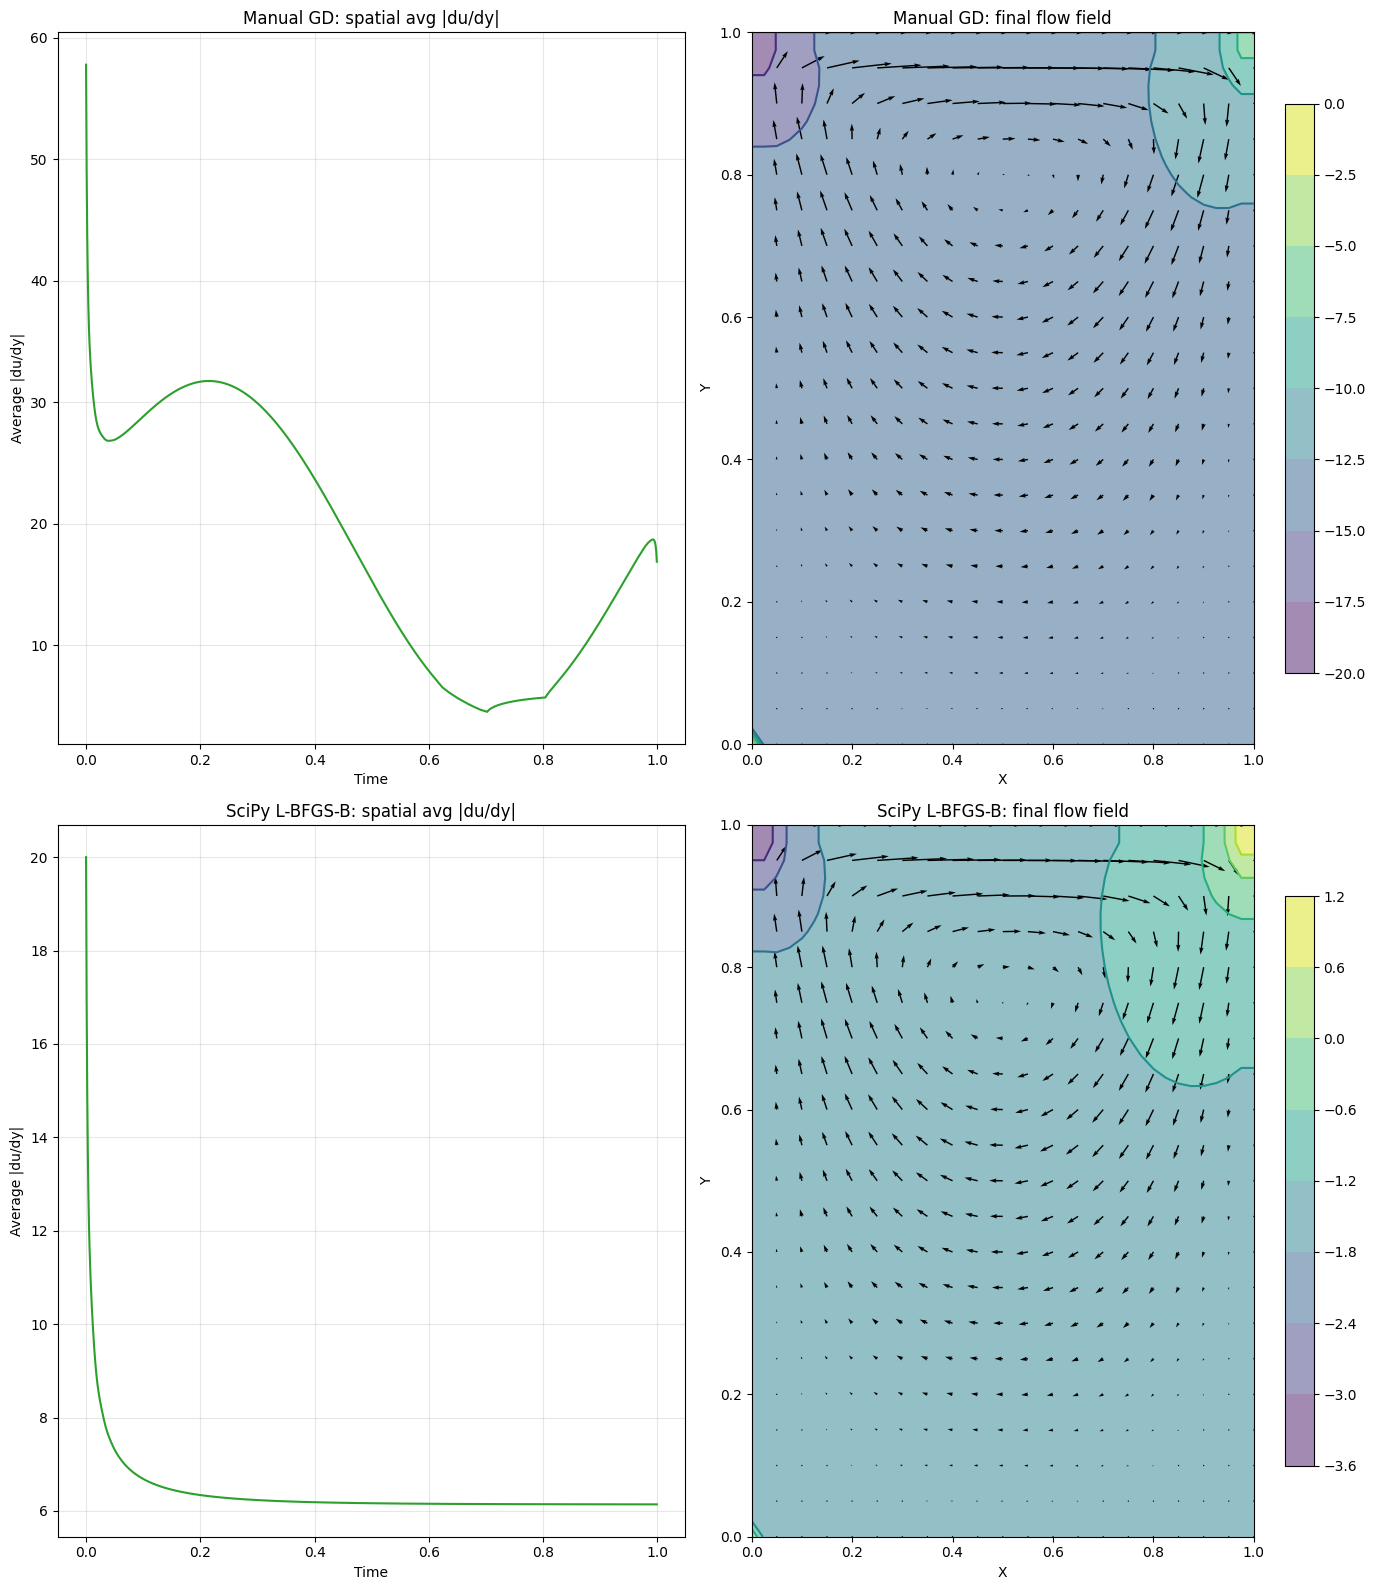

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 16))

for row, result in enumerate(results):
    a_opt = result["a"]
    u_opt, v_opt, p_opt, l_avg_opt, du_dy_hist_opt = run_sim(a_opt)
    spatial_drag_hist = jnp.mean(jnp.abs(du_dy_hist_opt), axis=1)

    axes[row, 0].plot(np.array(t), np.array(spatial_drag_hist), color="tab:green")
    axes[row, 0].set_title(f"{result['name']}: spatial avg |du/dy|")
    axes[row, 0].set_xlabel("Time")
    axes[row, 0].set_ylabel("Average |du/dy|")
    axes[row, 0].grid(alpha=0.3)

    cf = axes[row, 1].contourf(np.array(X), np.array(Y), np.array(p_opt), alpha=0.5, cmap="viridis")
    axes[row, 1].contour(np.array(X), np.array(Y), np.array(p_opt), cmap="viridis")
    axes[row, 1].quiver(
        np.array(X)[::2, ::2],
        np.array(Y)[::2, ::2],
        np.array(u_opt)[::2, ::2],
        np.array(v_opt)[::2, ::2],
    )
    axes[row, 1].set_title(f"{result['name']}: final flow field")
    axes[row, 1].set_xlabel("X")
    axes[row, 1].set_ylabel("Y")
    fig.colorbar(cf, ax=axes[row, 1], shrink=0.8)

plt.tight_layout()
plt.show()

#how spatial average of drag evolves over time
#drag appears to become more constant when optimized with constatn velocity
 


## 11 · SciPy `du/dy(x)` Profiles

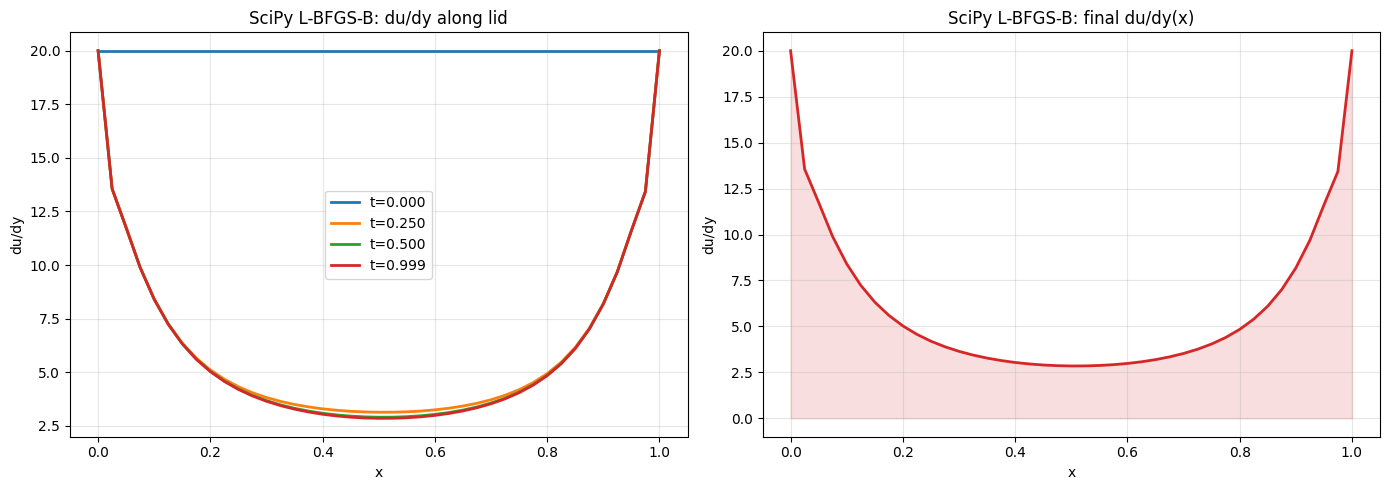

In [19]:
#plot of drag along the top wall lid (x) over different time steps

scipy_only = next(result for result in results if result["name"] == "SciPy L-BFGS-B")
_, _, _, _, scipy_du_dy_hist = run_sim(scipy_only["a"])

x_top = np.array(X[:, -1])

#time sampling
time_indices = [0, nt // 4, nt // 2, nt - 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx in time_indices:
    axes[0].plot(x_top, np.array(scipy_du_dy_hist[idx]), linewidth=2, label=f"t={float(t[idx]):.3f}")

axes[0].set_title("SciPy L-BFGS-B: du/dy along lid")
axes[0].set_xlabel("x")
axes[0].set_ylabel("du/dy")
axes[0].grid(alpha=0.3)
axes[0].legend()

final_du_dy = np.array(scipy_du_dy_hist[-1])
axes[1].plot(x_top, final_du_dy, color="tab:red", linewidth=2)
axes[1].fill_between(x_top, final_du_dy, 0.0, color="tab:red", alpha=0.15)
axes[1].set_title("SciPy L-BFGS-B: final du/dy(x)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("du/dy")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
